In [2]:
import netCDF4 as nc
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gc
import cartopy
import cartopy.crs as ccrs
from scipy.spatial import KDTree
from ll_xy import lonlat_to_xy
import pandas as pd
from regrid import regrid
from netCDF4 import Dataset
import xarray as xr

/home/robbie/anaconda3/envs/algae/lib/python3.13/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [3]:
IN_FILE = "../IS2-UMDRDA-NH-EASE2-25000m-v01-202208.nc"
OUT_NC = "../aux_data/ridge_fraction_derived.nc"


ds_in = nc.Dataset(IN_FILE)

sic = np.ma.filled(ds_in.variables["sea_ice_conc"][0], np.nan).astype("float32")
x = np.array(ds_in.variables["x_proj"][:], dtype="float32")
y = np.array(ds_in.variables["y_proj"][:], dtype="float32")
lat = np.array(ds_in.variables["latitude"][:], dtype="float32")
lon = np.array(ds_in.variables["longitude"][:], dtype="float32")

def ridge_fraction(w_name, d_name):
    W = np.ma.filled(ds_in.variables[w_name][0], np.nan).astype("float32")
    D = np.ma.filled(ds_in.variables[d_name][0], np.nan).astype("float32")
    with np.errstate(invalid="ignore", divide="ignore"):
        frac = W / D
    frac = np.where((D <= 0) | np.isnan(D) | np.isnan(W), np.nan, frac)
    frac = np.clip(frac, 0, 1)
    frac = np.where(sic >= 10, frac, np.nan)
    del W, D
    return frac.astype("float32")

frac60 = ridge_fraction("sail_W_T60", "sail_D_T60")
frac20 = ridge_fraction("sail_W_T20", "sail_D_T20")
ds_in.close()
gc.collect()

print("Ridge fraction (>0.6 m threshold): mean=%.4f median=%.4f n_valid=%d"
      % (np.nanmean(frac60), np.nanmedian(frac60), np.sum(~np.isnan(frac60))))
print("Ridge fraction (>0.2 m threshold): mean=%.4f median=%.4f n_valid=%d"
      % (np.nanmean(frac20), np.nanmedian(frac20), np.sum(~np.isnan(frac20))))

# ---- write a compact derived-variables NetCDF ----
ds_out = nc.Dataset(OUT_NC, "w", format="NETCDF4")
ds_out.createDimension("y", frac60.shape[0])
ds_out.createDimension("x", frac60.shape[1])
ds_out.createDimension("Time", 1)

v = ds_out.createVariable("x_proj", "f4", ("x",), zlib=True); v[:] = x; v.units = "km"
v = ds_out.createVariable("y_proj", "f4", ("y",), zlib=True); v[:] = y; v.units = "km"
v = ds_out.createVariable("latitude", "f4", ("y", "x"), zlib=True); v[:] = lat
v = ds_out.createVariable("longitude", "f4", ("y", "x"), zlib=True); v[:] = lon
v = ds_out.createVariable("sea_ice_conc", "f4", ("y", "x"), zlib=True, fill_value=np.nan); v[:] = sic; v.units = "%"

for varname, data, thresh_cm in [("ridge_fraction_T60", frac60, 60), ("ridge_fraction_T20", frac20, 20)]:
    v = ds_out.createVariable(varname, "f4", ("y", "x"), zlib=True, fill_value=np.nan)
    v[:] = data
    v.long_name = f"Linear (along-track) ridge fraction using {thresh_cm} cm sail-height threshold"
    v.units = "1"
ds_out.source_file = IN_FILE
ds_out.description = "Derived ridge-fraction variables computed from IS2-UMDRDA monthly gridded product, July 2022."
ds_out.close()
print("Wrote", OUT_NC)

Ridge fraction (>0.6 m threshold): mean=0.0302 median=0.0182 n_valid=5948
Ridge fraction (>0.2 m threshold): mean=0.0814 median=0.0646 n_valid=6500
Wrote ../aux_data/ridge_fraction_derived.nc


Wrote ../aux_data/ridge_fraction_derived.png


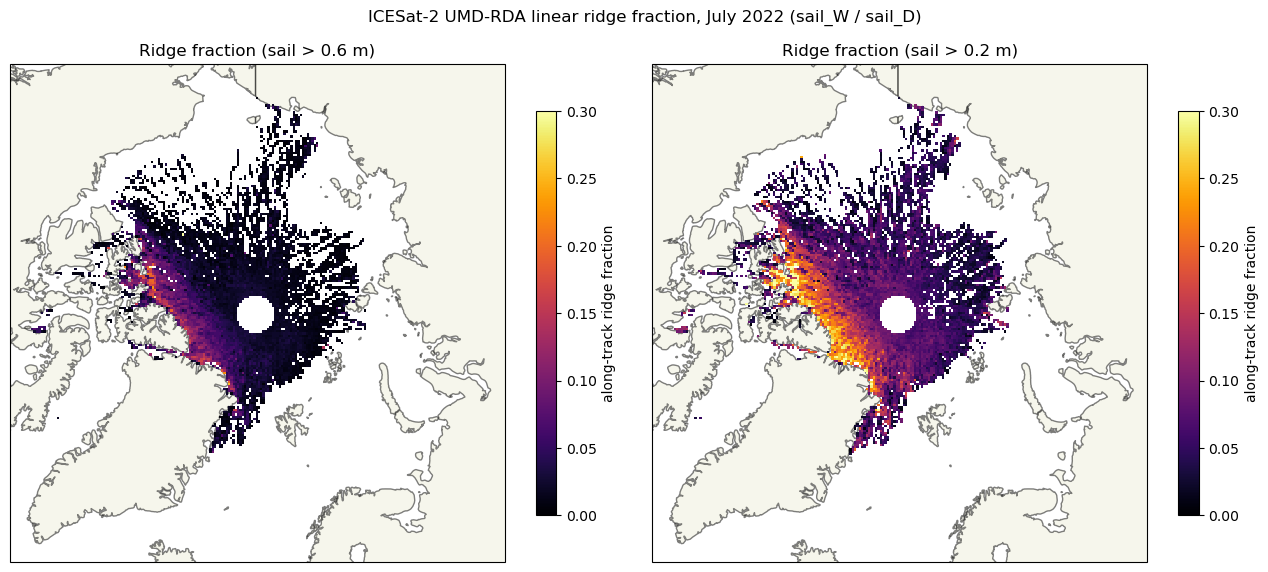

In [4]:
OUT_PNG = "../aux_data/ridge_fraction_derived.png"
# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                         subplot_kw={'projection':ccrs.NorthPolarStereo()})

for ax in axes:
    ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

cmap = plt.cm.inferno.copy()


for ax, frac, title in zip(axes, [frac60, frac20],
                             ["Ridge fraction (sail > 0.6 m)", "Ridge fraction (sail > 0.2 m)"]):
    im = ax.pcolormesh(lon, lat, frac, cmap=cmap,
                       norm=mcolors.Normalize(vmin=0, vmax=0.3),
                       shading="auto",
                       transform=ccrs.PlateCarree()
                       )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x_proj (km)")
    ax.set_ylabel("y_proj (km)")
    fig.colorbar(im, ax=ax, label="along-track ridge fraction", shrink=0.75)

fig.suptitle("ICESat-2 UMD-RDA linear ridge fraction, July 2022 (sail_W / sail_D)")
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=150)
print("Wrote", OUT_PNG)
plt.show()

In [5]:
conc=sic
conc[conc>0.1]=1
conc[conc<=0.1]=0
conc[np.isnan(conc)]=0
conc[lat<66]=0

In [6]:
x,y=lonlat_to_xy(lon,lat,hemisphere='n')

df = pd.DataFrame({'x':x.ravel(),'y':y.ravel(),'frac':frac60.ravel()})

In [7]:
inds_to_fill=np.argwhere(np.isnan(frac60)&(conc==1))
xys = [(x[i,j],y[i,j]) for i,j in inds_to_fill]

track_tree = KDTree(list(zip(df['x'],df['y'],)))



/tmp/ipykernel_6370/2078159747.py:2: RuntimeWarning: Mean of empty slice
  mean_fractions=[np.nanmean(df.iloc[ind]['frac']) for ind in tree_output[1]]


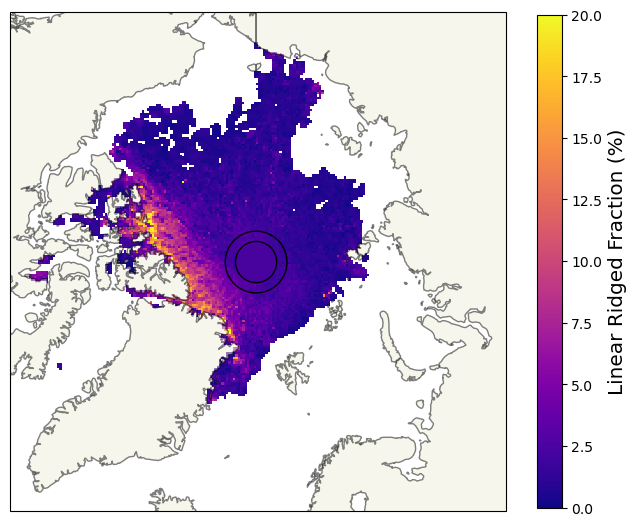

In [12]:
tree_output=track_tree.query(xys,k=10)
mean_fractions=[np.nanmean(df.iloc[ind]['frac']) for ind in tree_output[1]]

frac_grid_filled=frac60.copy()
for (i,j),mean_frac in zip(inds_to_fill,mean_fractions):
    frac_grid_filled[i,j] = mean_frac

frac_grid_filled[lat>88]=np.nanmean(frac_grid_filled[(lat>87)&(lat<88)])

# frac_grid_filled[conc<0.1]=np.nan

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(lon,
                  lat,
                  100*frac_grid_filled,
                  vmin = 0,
                  vmax = 20,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

ax.gridlines(ylocs=[87,88],xlocs=[],color='k',linewidth=1,zorder=10)

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')
plt.savefig('../figs/rf.png',dpi=500,bbox_inches='tight')

In [13]:
conc=np.array(Dataset('inputs/conc.nc')['sea_ice_conc'])
psn_lon=np.array(Dataset('inputs/conc.nc')['longitude'])
psn_lat=np.array(Dataset('inputs/conc.nc')['latitude'])

rf = regrid(frac_grid_filled,lon,lat,psn_lon,psn_lat)
rf[conc<=0.1]=np.nan

/tmp/ipykernel_6370/732364899.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc=np.array(Dataset('inputs/conc.nc')['sea_ice_conc'])
/tmp/ipykernel_6370/732364899.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  psn_lon=np.array(Dataset('inputs/conc.nc')['longitude'])
/tmp/ipykernel_6370/732364899.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword argume

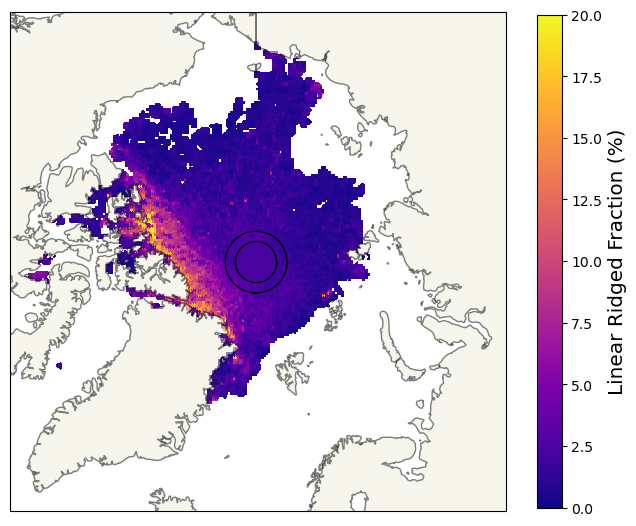

In [14]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  rf*100,
                  vmin = 0,
                  vmax = 20,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

ax.gridlines(ylocs=[87,88],xlocs=[],color='k',linewidth=1,zorder=10)

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')

In [16]:
dnc = xr.DataArray(name='ridged_fraction_filled',
    data=rf,
    coords={'latitude':(['x','y'],psn_lat),
            'longitude':(['x','y'],psn_lon),
           },
    dims=['x','y'],
)

dnc.to_netcdf('../aux_data/rf.nc')
dnc.to_netcdf('inputs/rf.nc')

dnc.to_netcdf('/home/robbie/uit_mnt/home/romal7177/algae/inputs/rf.nc')

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: /home/robbie/uit_mnt/home/romal7177/algae/inputs/rf.nc: Operation not supported
